In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Professional plot styling
plt.style.use('seaborn-v0_8-darkgrid')

# Load the weather data
df_weather = pd.read_csv('../data/weather_data_2024_2025.csv', parse_dates=['timestamp'], index_col='timestamp')

# Basic info
print("Dataset Shape:", df_weather.shape)
print("\nMissing Values:\n", df_weather.isna().sum())

# Quick statistical summary
display(df_weather.describe())

Dataset Shape: (17544, 2)

Missing Values:
 temperature_2m_C        0
solar_radiation_W_m2    0
dtype: int64


,temperature_2m_C,solar_radiation_W_m2
count,17544.000000,17544.000000
mean,11.654132,138.834131
std,7.905681,211.861021
min,-7.800000,0.000000
25%,5.700000,0.000000
50%,11.350000,6.000000
75%,17.300000,216.000000
max,38.200000,906.000000


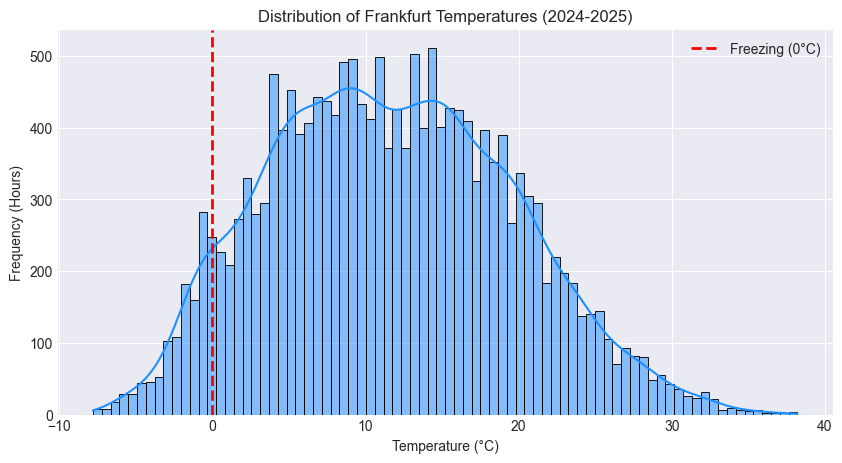

Total hours below freezing: 1191 (6.8% of the time)


In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(df_weather['temperature_2m_C'], bins=80, kde=True, color='dodgerblue')
plt.title('Distribution of Frankfurt Temperatures (2024-2025)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency (Hours)')

# Draw a red line at Freezing (0°C)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Freezing (0°C)')
plt.legend()
plt.show()

freezing_hours = (df_weather['temperature_2m_C'] < 0).sum()
total_hours = len(df_weather)
print(f"Total hours below freezing: {freezing_hours} ({freezing_hours/total_hours*100:.1f}% of the time)")

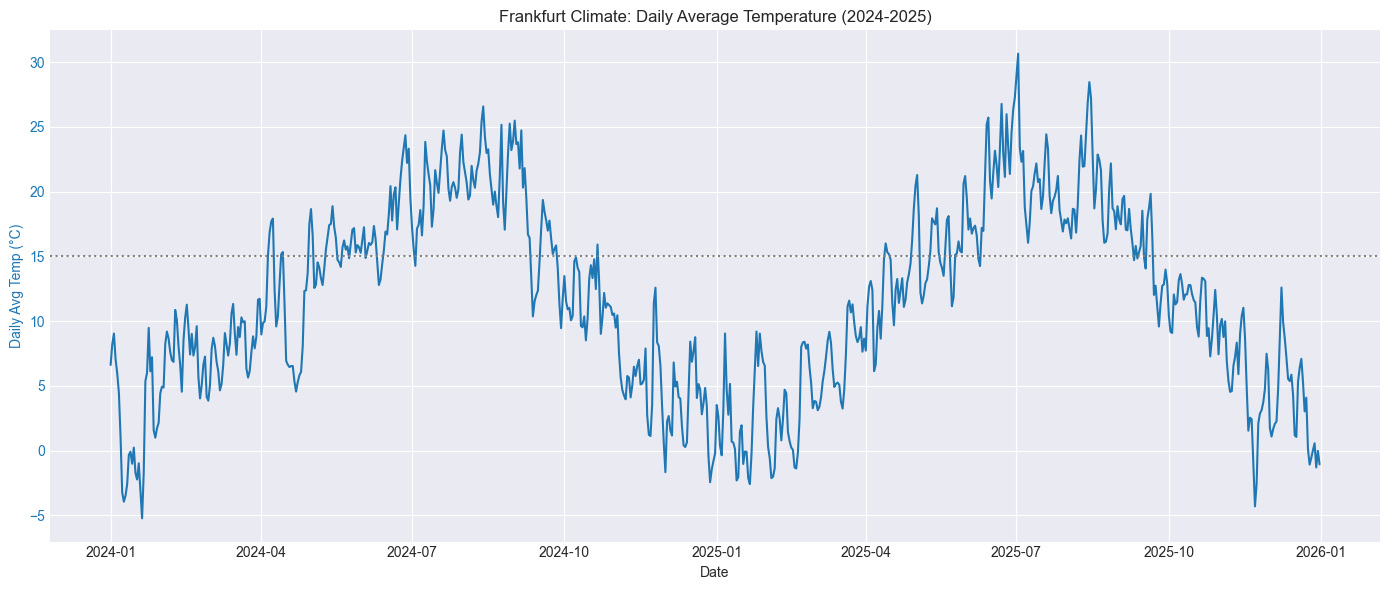

In [4]:
# Resample to Daily Averages ('D')
df_daily = df_weather.resample('D').mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Temperature
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Avg Temp (°C)', color=color)
ax1.plot(df_daily.index, df_daily['temperature_2m_C'], color=color, linewidth=1.5, label='Temperature')
ax1.tick_params(axis='y', labelcolor=color)

# Add a horizontal line for the "Heating Threshold" (approx 15°C)
ax1.axhline(15, color='gray', linestyle=':', label='Heating required below 15°C')

plt.title('Frankfurt Climate: Daily Average Temperature (2024-2025)')
fig.tight_layout()
plt.show()

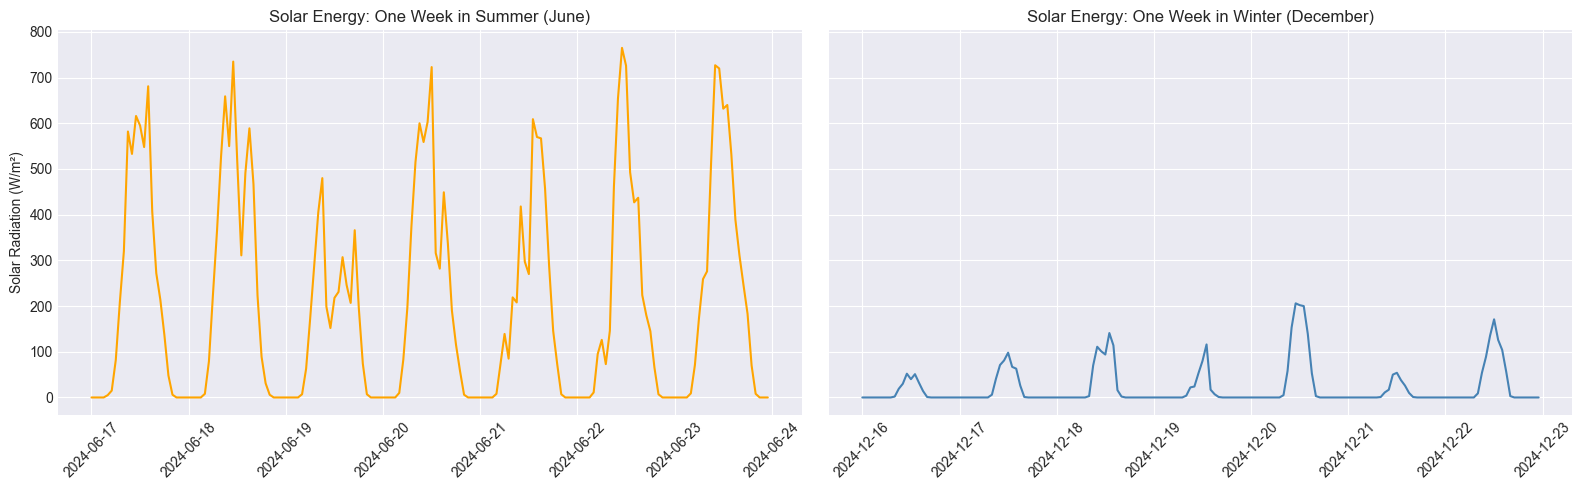

In [5]:
# Extract a summer week and a winter week
summer_week = df_weather.loc['2024-06-17':'2024-06-23']
winter_week = df_weather.loc['2024-12-16':'2024-12-22']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Summer Plot
axes[0].plot(summer_week.index, summer_week['solar_radiation_W_m2'], color='orange')
axes[0].set_title('Solar Energy: One Week in Summer (June)')
axes[0].set_ylabel('Solar Radiation (W/m²)')
axes[0].tick_params(axis='x', rotation=45)

# Winter Plot
axes[1].plot(winter_week.index, winter_week['solar_radiation_W_m2'], color='steelblue')
axes[1].set_title('Solar Energy: One Week in Winter (December)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()